In [12]:
import os
import utils.dataset_preprocessing as dprepro
import utils.image_display as imd
import shutil
import glob
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed
import multiprocessing as mp
import ants

In [7]:
#ROOT_DIR = "/home/fehrdelt/bettik/"
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

In [8]:

original_folder_skullstrip = f"{ROOT_DIR}datasets/processed_files_aini_stroke_export_adc_flair_pred_nihss_2022_2023_skullstrip"

In [9]:
unique_names = set()
for filename in os.listdir(original_folder_skullstrip):
    if filename.endswith(".nii.gz"):
        unique_name = filename.split("_")[0]  # Extract the part before the first underscore
        unique_names.add(unique_name)

In [14]:
adc_unprocessed_folder = ROOT_DIR+"/datasets/final_aini_stroke_dataset_small/adc_unprocessed/"
os.makedirs(adc_unprocessed_folder, exist_ok=True)

adc_resized_folder = ROOT_DIR+"/datasets/final_aini_stroke_dataset_small/adc_resized/"
os.makedirs(adc_resized_folder, exist_ok=True)

adc_final_registered_folder = ROOT_DIR+"/datasets/final_aini_stroke_dataset_small/adc_registered/"
os.makedirs(adc_final_registered_folder, exist_ok=True)



flair_unprocessed_folder = ROOT_DIR+"/datasets/final_aini_stroke_dataset_small/flair_unprocessed/"
os.makedirs(flair_unprocessed_folder, exist_ok=True)

flair_resized_folder = ROOT_DIR+"/datasets/final_aini_stroke_dataset_small/flair_resized/"
os.makedirs(flair_resized_folder, exist_ok=True)

flair_final_registered_folder = ROOT_DIR+"/datasets/final_aini_stroke_dataset_small/flair_registered/"
os.makedirs(flair_final_registered_folder, exist_ok=True)

In [ ]:
adc = []
flair = []

for name in tqdm(unique_names):
    adc_files = glob.glob(os.path.join(original_folder_skullstrip, f"{name}*_ADC.nii.gz"))
    flair_files = glob.glob(os.path.join(original_folder_skullstrip, f"{name}*_FLAIR.nii.gz"))
    
    if adc_files and flair_files:
        #print(f"Found for {name}:")
        #print(f"  ADC: {adc_files[0]}")
        #print(f"  FLAIR: {flair_files[0]}")
        adc.append(adc_files[0])
        flair.append(flair_files[0])

        new_adc_path = os.path.join(adc_unprocessed_folder, f"{name}.nii.gz")
        new_flair_path = os.path.join(flair_unprocessed_folder, f"{name}.nii.gz")
        
        shutil.copy(adc_files[0], new_adc_path)
        shutil.copy(flair_files[0], new_flair_path)
        
        # Updating the list to point to the new paths for subsequent cells
        adc[-1] = new_adc_path
        flair[-1] = new_flair_path

  7%|█████████████▌                                                                                                                                                                                     | 17/245 [00:04<00:48,  4.74it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 245/245 [00:49<00:00,  4.94it/s]


### ADC

Image 1 shape: (260, 256, 28)
Image 2 shape: (280, 280, 36)
Image 3 shape: (280, 280, 36)
Image 4 shape: (260, 256, 30)


<Figure size 640x480 with 0 Axes>

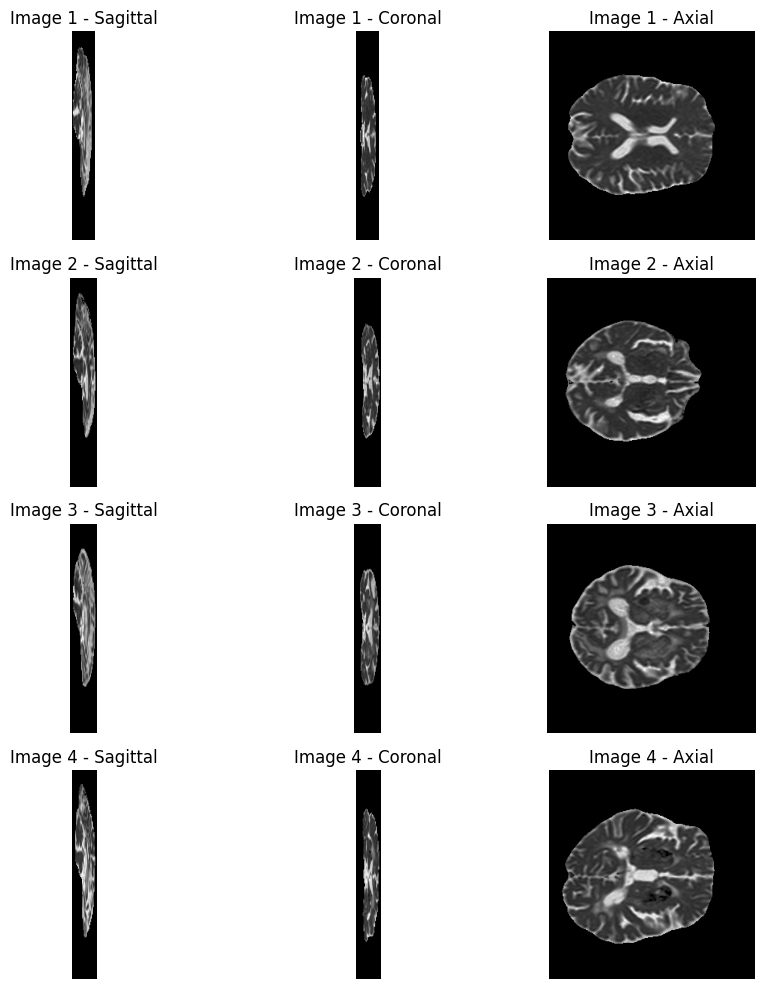

In [16]:
imd.show_first_4_nifti(adc_unprocessed_folder)

In [17]:
dprepro.resample_nifti_files_folder_multithreaded(
    adc_unprocessed_folder,
    adc_resized_folder,
    out_spacing=[1,1,1],
    max_workers=48)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 225/225 [00:10<00:00, 21.93it/s]


Image 1 shape: (230, 226, 146)
Image 2 shape: (230, 230, 158)
Image 3 shape: (230, 230, 158)
Image 4 shape: (230, 226, 156)


<Figure size 640x480 with 0 Axes>

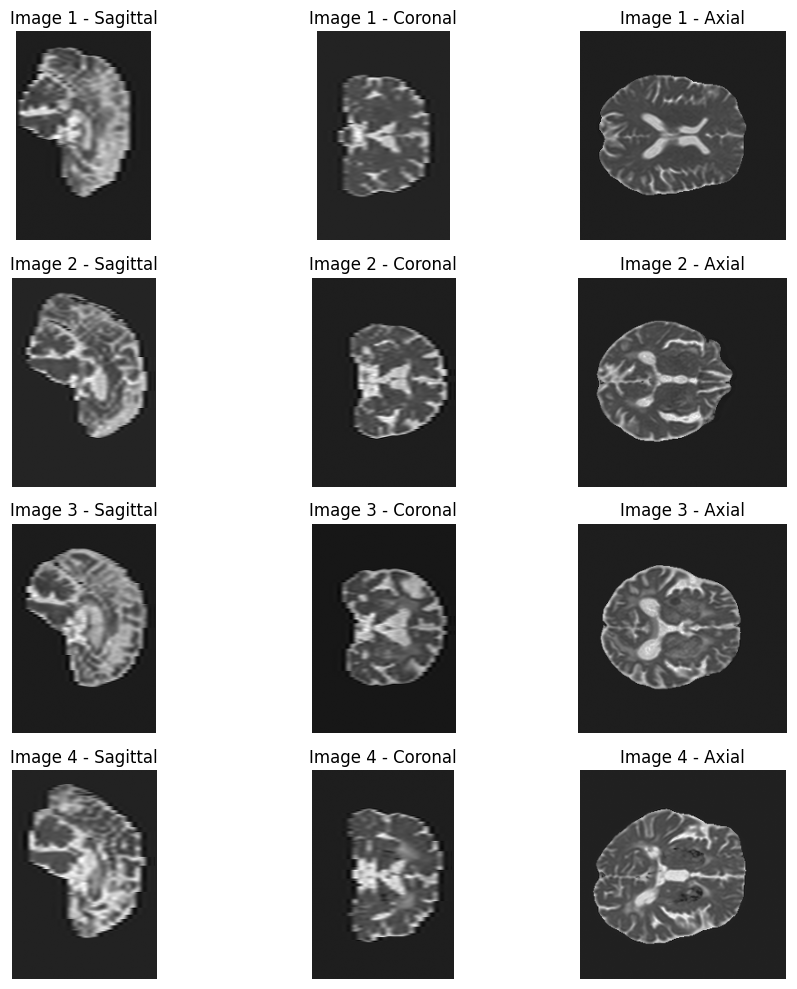

In [18]:
imd.show_first_4_nifti(adc_resized_folder)

In [20]:
def orient_to_ras(file_path):
    img = sitk.ReadImage(file_path)
    img_ras = sitk.DICOMOrient(img, 'RAS')
    sitk.WriteImage(img_ras, file_path)

adc_resized_files = glob.glob(os.path.join(adc_resized_folder, "*.nii.gz"))

# n_jobs=-1 uses all available processor cores
_ = Parallel(n_jobs=-1)(
    delayed(orient_to_ras)(f) for f in tqdm(adc_resized_files, desc="Orienting ADC to RAS")
)

Orienting ADC to RAS:   0%|                                                                                                                                                                                      | 0/225 [00:00<?, ?it/s]

Image 1 shape: (230, 226, 146)
Image 2 shape: (230, 230, 158)
Image 3 shape: (230, 230, 158)
Image 4 shape: (230, 226, 156)


<Figure size 640x480 with 0 Axes>

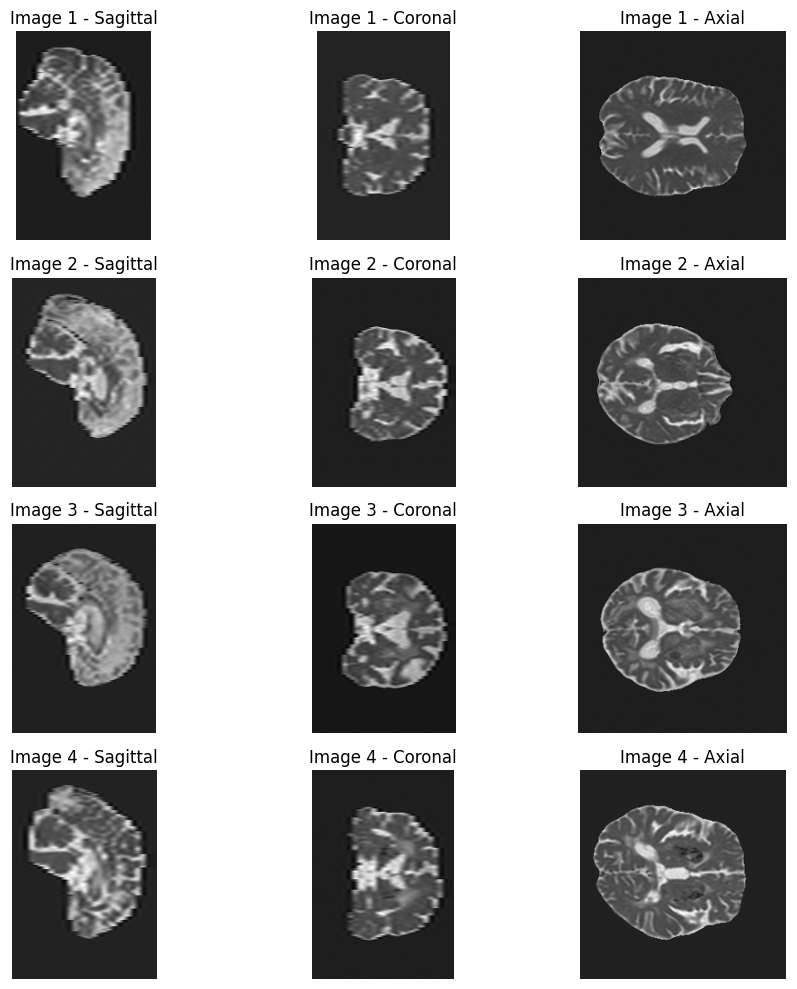

In [21]:
imd.show_first_4_nifti(adc_resized_folder)

In [22]:

adc_template_path = ROOT_DIR + "datasets/mni_icbm152_nlin_sym_09a/template_adc_128.nii.gz"

In [23]:
# images and masks
dprepro.register_nifti_files_folder_multithreaded(
    fixed_reference=adc_template_path,
    dataset_path=adc_resized_folder,
    output_path = adc_final_registered_folder,
    register_masks=False,
    max_workers=48
)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 225/225 [03:30<00:00,  1.07it/s]


Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)


<Figure size 640x480 with 0 Axes>

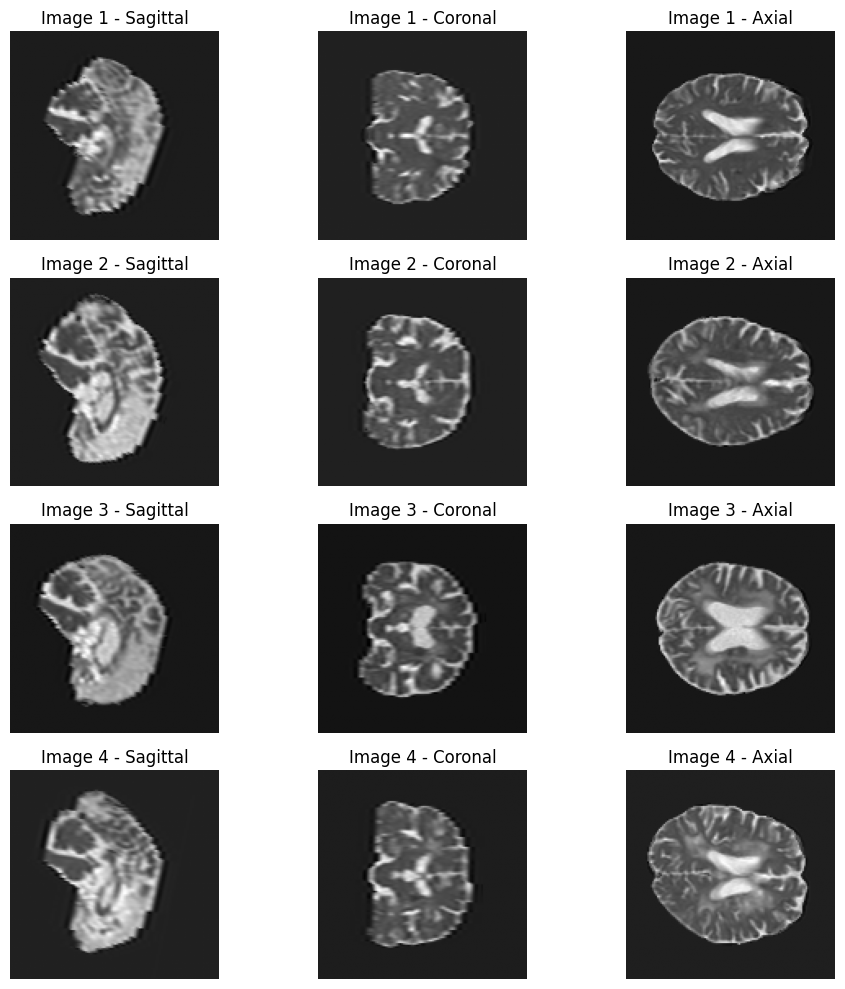

In [24]:
imd.show_first_4_nifti(adc_final_registered_folder)

### FLAIR

In [25]:
dprepro.resample_nifti_files_folder_multithreaded(
    flair_unprocessed_folder,
    flair_resized_folder,
    out_spacing=[1,1,1],
    max_workers=48)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 225/225 [00:13<00:00, 16.72it/s]


Image 1 shape: (194, 230, 155)
Image 2 shape: (230, 230, 154)
Image 3 shape: (230, 230, 154)
Image 4 shape: (194, 230, 155)


<Figure size 640x480 with 0 Axes>

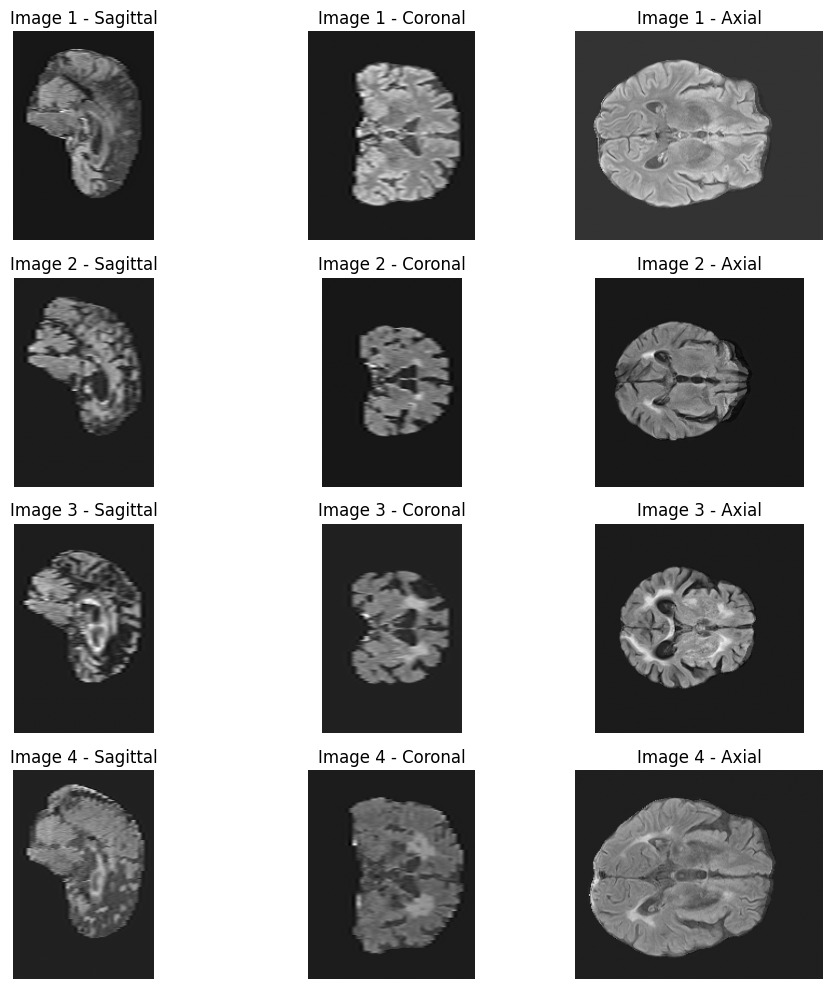

In [26]:
imd.show_first_4_nifti(flair_resized_folder)

In [27]:
def orient_to_ras(file_path):
    img = sitk.ReadImage(file_path)
    img_ras = sitk.DICOMOrient(img, 'RAS')
    sitk.WriteImage(img_ras, file_path)

flair_resized_files = glob.glob(os.path.join(flair_resized_folder, "*.nii.gz"))

# n_jobs=-1 uses all available processor cores
_ = Parallel(n_jobs=-1)(
    delayed(orient_to_ras)(f) for f in tqdm(flair_resized_files, desc="Orienting ADC to RAS")
)

Orienting ADC to RAS:  21%|████████████████████████████████████▋                                                                                                                                       | 48/225 [00:00<00:00, 197.40it/s]

Image 1 shape: (194, 230, 155)
Image 2 shape: (230, 230, 154)
Image 3 shape: (230, 230, 154)
Image 4 shape: (194, 230, 155)


<Figure size 640x480 with 0 Axes>

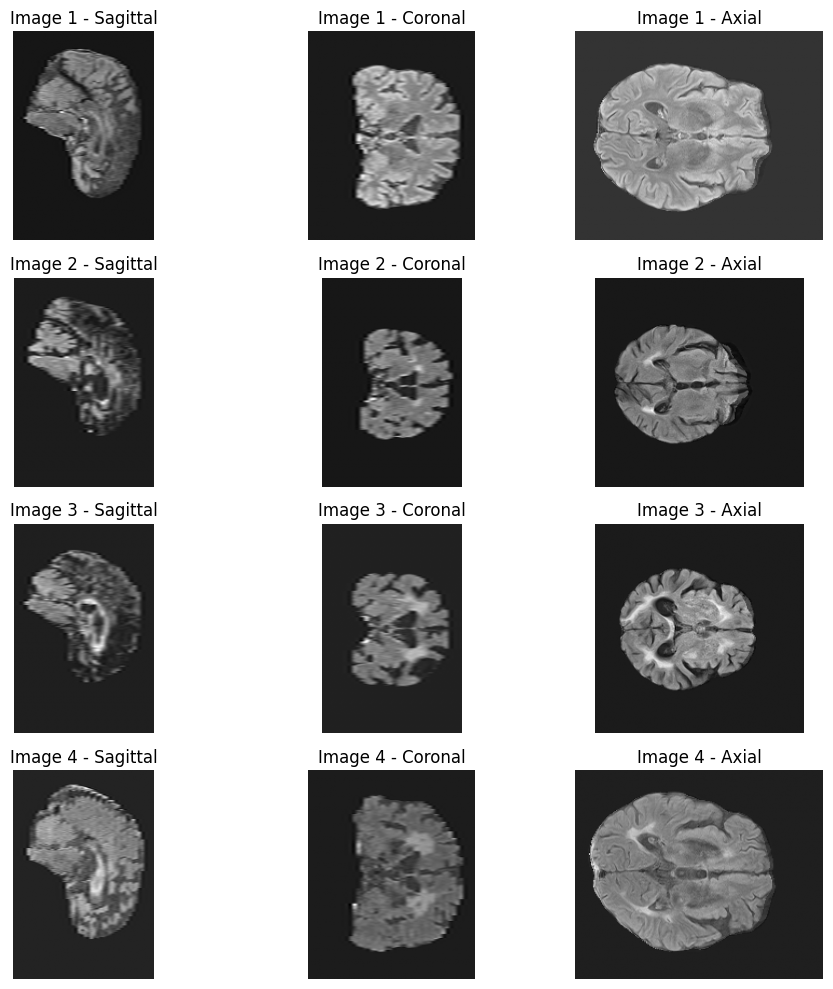

In [28]:
imd.show_first_4_nifti(flair_resized_folder)

In [29]:

flair_template_path = ROOT_DIR + "datasets/mni_icbm152_nlin_sym_09a/template_flair_128.nii.gz"

In [30]:
# images and masks
dprepro.register_nifti_files_folder_multithreaded(
    fixed_reference=flair_template_path,
    dataset_path=flair_resized_folder,
    output_path = flair_final_registered_folder,
    register_masks=False,
    max_workers=48
)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 225/225 [03:22<00:00,  1.11it/s]


Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)


<Figure size 640x480 with 0 Axes>

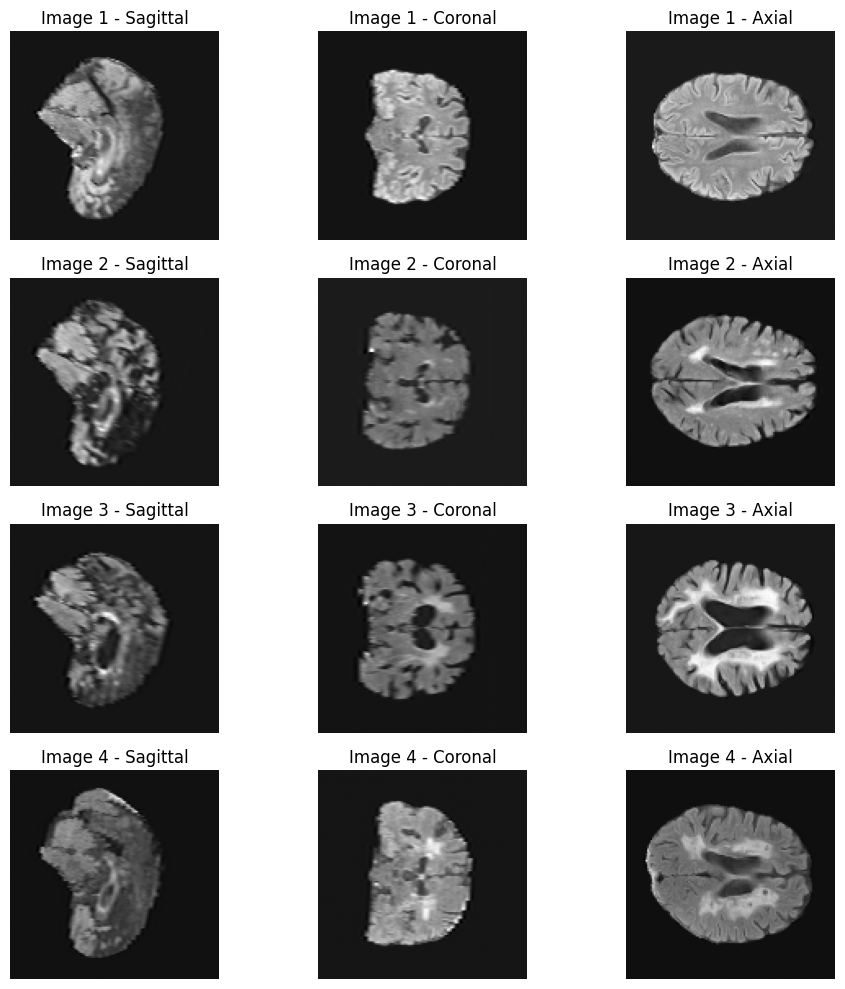

In [31]:
imd.show_first_4_nifti(flair_final_registered_folder)